<a href="https://colab.research.google.com/github/fakhrulfaiz/FoodFinder/blob/main/stock_price_prediction_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [9]:
ticker = 'AAPL'
df = yf.download(ticker, start='2020-01-01')

df.head()

/tmp/ipykernel_2891/537248121.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2020-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696617,72.455935,71.472439,71.629122,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928070,72.533110,71.708710,72.277594,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [13]:
df.dtypes

,,0
Price,Ticker,
Close,AAPL,float64
High,AAPL,float64
Low,AAPL,float64
Open,AAPL,float64
Volume,AAPL,int64


<Axes: xlabel='Date'>

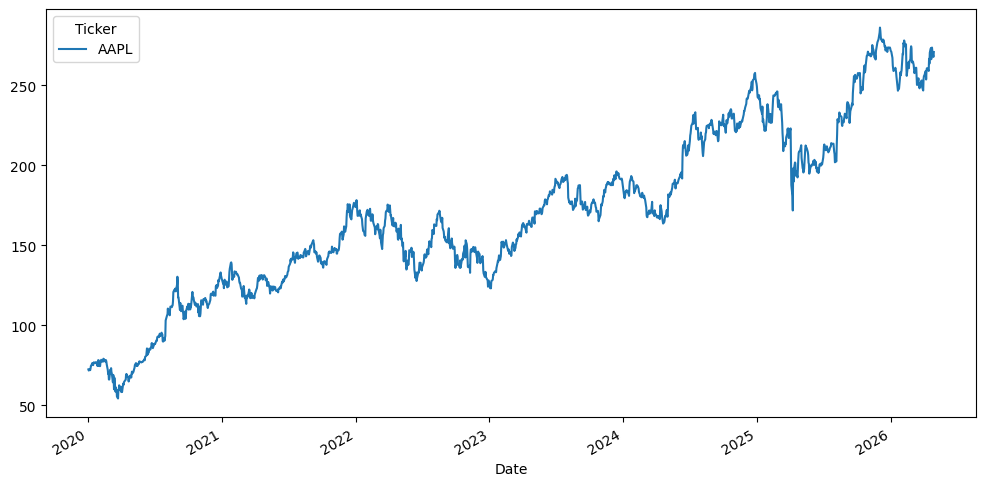

In [15]:
df.Close.plot(figsize=(12, 6))

In [16]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df[['Close']])


In [34]:
seq_length = 30
data = []

values = df.Close.values

for i in range(len(values) - seq_length):
    seq = values[i:i + seq_length]
    data.append(seq)

data = np.array(data)


data = data.reshape(data.shape[0], data.shape[1], 1)

In [35]:
train_size = int(len(data) * 0.8)

X_train = torch.from_numpy(data[:train_size, :-1, :]).float()
y_train = torch.from_numpy(data[:train_size, -1, :]).float()

X_test = torch.from_numpy(data[train_size:, :-1, :]).float()
y_test = torch.from_numpy(data[train_size:, -1, :]).float()

In [36]:
print(X_train.shape)
print(y_train.shape)

torch.Size([1246, 29, 1])
torch.Size([1246, 1])


In [37]:
class PredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):

        # ensure same device as input
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        out, _ = self.lstm(x, (h0, c0))

        out = self.fc(out[:, -1, :])

        return out

In [38]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)
model.to(device)

PredictionModel(
  (lstm): LSTM(1, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)

In [39]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr= 0.01)


In [40]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

In [43]:
num_epochs = 200

model.train()

for epoch in range(num_epochs):

    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    if epoch % 25 == 0:
        print(epoch, total_loss / len(train_loader))

0 0.0028619220844493844
25 0.0030972605499510583
50 0.0029578226624438777
75 0.003426396487973248
100 0.00272685725791141
125 0.0029149378428999814
150 0.0030476919238049635
175 0.0025097509869971336


In [51]:
model.eval()

train_preds = []

train_loader_eval = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False
)
with torch.no_grad():
    for X_batch, _ in train_loader_eval:
        pred = model(X_batch)
        train_preds.append(pred)

y_train_pred = torch.cat(train_preds, dim=0)

In [52]:
with torch.no_grad():
    y_test_pred = model(X_test)

In [53]:
y_train_pred = scaler.inverse_transform(y_train_pred.numpy())
y_test_pred = scaler.inverse_transform(y_test_pred.numpy())

In [54]:
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

In [55]:
print(f'Train RMSE: {train_rmse:.4f}')
print(f'Test RMSE: {test_rmse:.4f}')


Train RMSE: 3.0351
Test RMSE: 5.3011


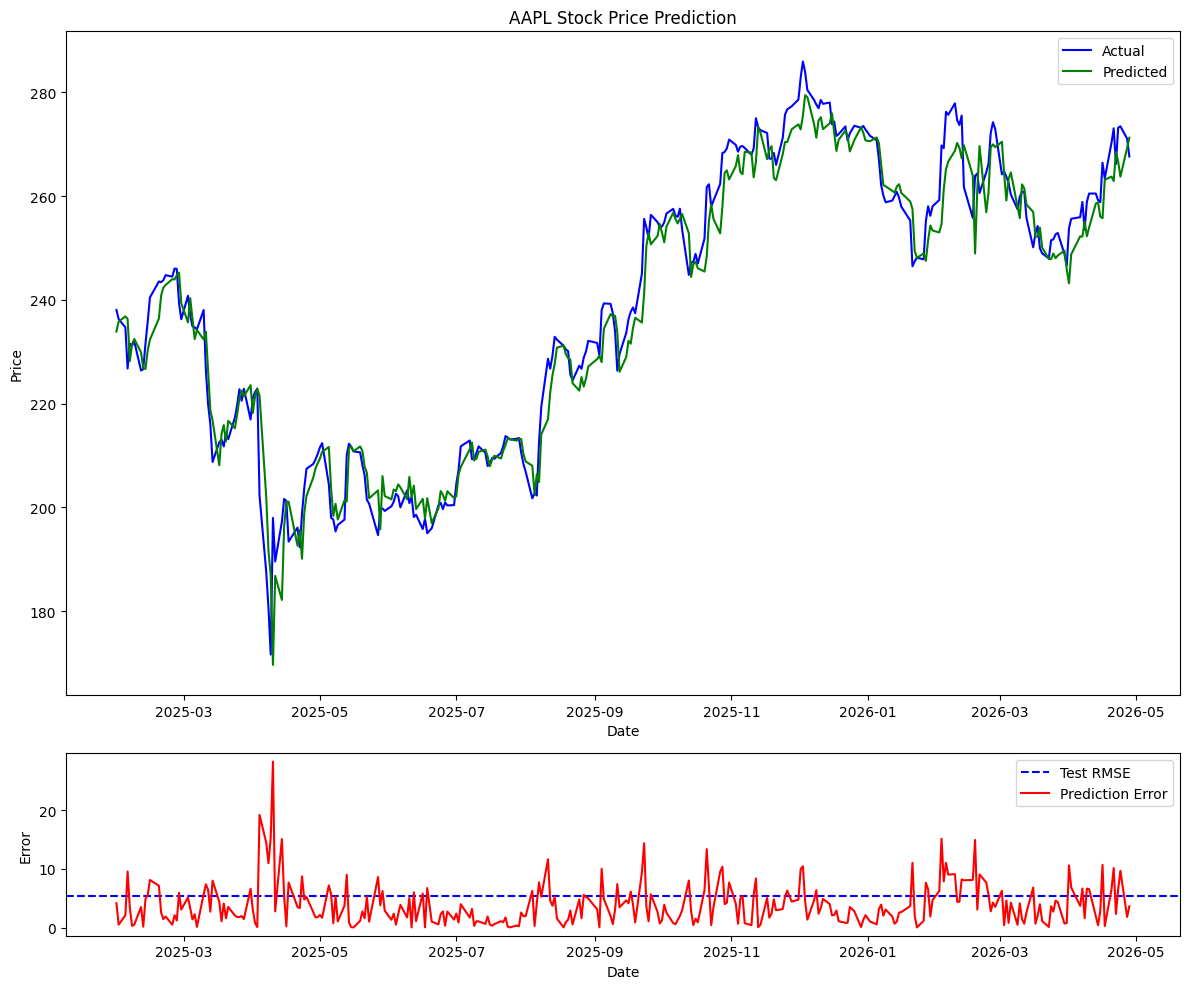

In [56]:
fig = plt.figure(figsize=(12, 10))

gs = fig.add_gridspec(4, 1)

ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(y_test):].index, y_test, color='blue', label='Actual')
ax1.plot(df.iloc[-len(y_test):].index, y_test_pred, color='green', label='Predicted')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color= 'blue', linestyle= '--', label= 'Test RMSE')
ax2.plot(df[-len(y_test):].index, abs(y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend()
plt.xlabel("Date")
plt.ylabel("Error")

plt.tight_layout()
plt.show()